# 260410
Cubic loop model のトイモデル計算

## 3 by 3 OBC


<img src="images/drive-image.jpg" alt="drive-image" width="320">

In [104]:
from pathlib import Path
import requests

file_id = "1vy_O0-VKBX76QTKeytXg8IFQN0TXwOdb"
download_url = f"https://drive.usercontent.google.com/download?id={file_id}&export=view"

img_dir = Path("images")
img_dir.mkdir(exist_ok=True)
img_path = img_dir / "drive-image.jpg"

r = requests.get(download_url, timeout=30)
r.raise_for_status()
img_path.write_bytes(r.content)

print(f"saved: {img_path}")
print(f"bytes: {img_path.stat().st_size}")

saved: images/drive-image.jpg
bytes: 153644


### 分配関数を手計算

In [105]:
def Weight_i_g0(x, n):
    return n**9

In [106]:
def Weight_f_g0(x, n):
    return 1

In [107]:
def Weight_i_g1(x, n):
    return (x**4) * (n**6)

In [108]:
def Weight_f_g1(x, n):
    return (x**4) * n

In [109]:
def Weight_i_g2(x, n):
    return (x**6) * (n**4)

In [110]:
def Weight_f_g2(x, n):
    return (x**6) * n

In [111]:
def Weight_i_g3(x, n):
    return (x**6) * (n**4)

In [112]:
def Weight_f_g3(x, n):
    return (x**6) * n

In [113]:
def Weight_i_g4(x, n):
    return (x**8) * (n**3)

In [114]:
def Weight_f_g4(x, n):
    return (x**8) * (n**2)

In [115]:
def Weight_i_g5(x, n):
    return (x**8) * (n**2)

In [116]:
def Weight_f_g5(x, n):
    return (x**8) * n

In [117]:
def Weight_i_g6(x, n):
    return (x**8) * (n**2)

In [118]:
def Weight_f_g6(x, n):
    return (x**8) * n

In [119]:
def PF_i(x, n):
    func =  Weight_i_g0(x, n) + 4 * Weight_i_g1(x, n) + 2 * Weight_i_g2(x, n) + 2 * Weight_i_g3(x, n) \
        + 2 * Weight_i_g4(x, n) + 4 * Weight_i_g5(x, n) + Weight_i_g6(x, n)
    return (2**9) * func

In [121]:
def PF_f(x, n):
    func =  Weight_f_g0(x, n) + 4 * Weight_f_g1(x, n) + 2 * Weight_f_g2(x, n) + 2 * Weight_f_g3(x, n) \
        + 2 * Weight_f_g4(x, n) + 4 * Weight_f_g5(x, n) + Weight_f_g6(x, n)
    return (2**9) * (n**9) * func

#### 分配関数の差の計算

saved: pf_ratio_csv/PF_ratio_n1.csv
saved: pf_ratio_csv/PF_ratio_n2.csv
saved: pf_ratio_csv/PF_ratio_n3.csv
saved: pf_ratio_csv/PF_ratio.png


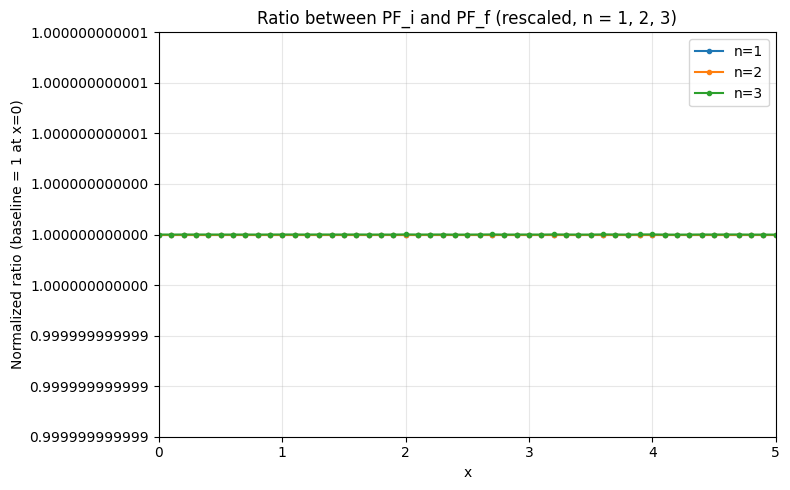

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import FormatStrFormatter

x_max = 10.0
x_values = np.arange(0.0, x_max + 1e-9, 0.1)
n_values = [1, 2, 3]

out_dir = Path("pf_ratio_csv")
out_dir.mkdir(exist_ok=True)
png_path = out_dir / "PF_ratio.png"

plt.figure(figsize=(8, 5))
all_ratio_unit1 = []
for n in n_values:
    ratio_values = []
    for x in x_values:
        numerator = PF_i(x, n)
        denominator = PF_f(x / n, n)
        ratio_values.append(np.nan if np.isclose(denominator, 0.0) else numerator / denominator)

    ratio_values = np.array(ratio_values, dtype=float)

    # Re-define y-axis unit so each curve is around 1 (baseline at x=0).
    finite_idx = np.where(np.isfinite(ratio_values))[0]
    if finite_idx.size == 0:
        ratio_unit1 = np.full_like(ratio_values, np.nan, dtype=float)
    else:
        base = ratio_values[finite_idx[0]]
        ratio_unit1 = ratio_values / base

    all_ratio_unit1.append(ratio_unit1)
    plt.plot(x_values, ratio_unit1, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

    csv_path = out_dir / f"PF_ratio_n{n}.csv"
    data = np.column_stack((x_values, ratio_values, ratio_unit1))
    np.savetxt(
        csv_path,
        data,
        delimiter=",",
        header="x,PF_i_div_PF_f,PF_i_div_PF_f_unit1",
        comments="",
    )
    print(f"saved: {csv_path}")

# Make y-axis display around 1 directly (disable offset/scientific style).
all_ratio_unit1 = np.concatenate(all_ratio_unit1)
finite_vals = all_ratio_unit1[np.isfinite(all_ratio_unit1)]
center = np.nanmean(finite_vals) if finite_vals.size else 1.0
spread = np.nanmax(np.abs(finite_vals - center)) if finite_vals.size else 1e-12
pad = max(spread * 1.2, 1e-12)
plt.ylim(center - pad, center + pad)

ax = plt.gca()
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.12f"))

plt.xlabel("x")
plt.ylabel("Normalized ratio (baseline = 1 at x=0)")
plt.title("Ratio between PF_i and PF_f (rescaled, n = 1, 2, 3)")
plt.xlim(0, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(png_path, dpi=300, bbox_inches="tight")
print(f"saved: {png_path}")
plt.show()

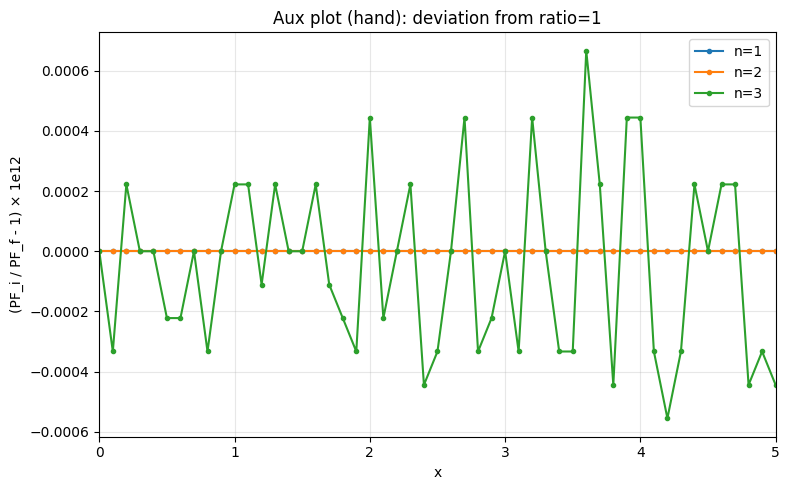

In [123]:
# 手計算側の補助プロット: 縦軸は (PF_i / PF_f - 1) × 1e12
x_values = np.arange(0.0, 5.0 + 1e-9, 0.1)
n_values = [1, 2, 3]

scale = 1e12
plt.figure(figsize=(8, 5))
for n in n_values:
    ratio_minus_1 = []
    for x in x_values:
        num = PF_i(x, n)
        den = PF_f(x / n, n)
        if np.isclose(den, 0.0):
            ratio_minus_1.append(np.nan)
        else:
            ratio_minus_1.append(num / den - 1.0)

    y = np.array(ratio_minus_1, dtype=float) * scale
    plt.plot(x_values, y, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

plt.xlabel("x")
plt.ylabel("(PF_i / PF_f - 1) × 1e12")
plt.title("Aux plot (hand): deviation from ratio=1")
plt.xlim(0, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(Path("pf_ratio_csv") / "PF_ratio_deviation.png", dpi=300, bbox_inches="tight")
plt.show()

saved: PF_i_log_over_9.png


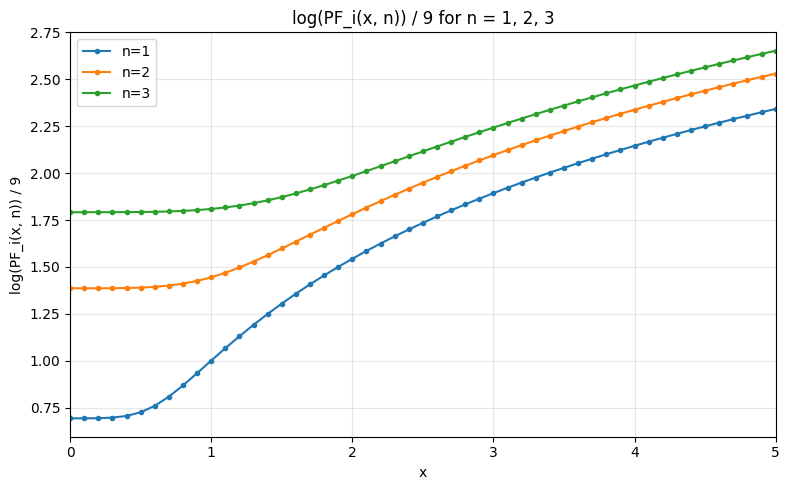

In [124]:
from pathlib import Path

x_values = np.arange(0.0, 5.0 + 1e-9, 0.1)
n_values = [1, 2, 3]

png_path = Path("PF_i_log_over_9.png")

plt.figure(figsize=(8, 5))
for n in n_values:
    y_values = [np.log(PF_i(x, n)) / 9.0 for x in x_values]
    plt.plot(x_values, y_values, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

plt.xlabel("x")
plt.ylabel("log(PF_i(x, n)) / 9")
plt.title("log(PF_i(x, n)) / 9 for n = 1, 2, 3")
plt.xlim(0, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(png_path, dpi=300, bbox_inches="tight")
print(f"saved: {png_path}")
plt.show()

### 分配関数を TN で計算

In [125]:
def CL3by3OBC_TensorI_Cornor(x, n):
    T = np.zeros((n+1, n+1))
    for i in range(n+1):
        T[i, i] = n if i == 0 else x
    return T

In [63]:
CL3by3OBC_TensorI_Cornor(2, 1)

array([[1., 0.],
       [0., 2.]])

In [126]:
def CL3by3OBC_TensorF_Cornor(x, n):
    return np.diag([1] + [x] * (n))

In [66]:
CL3by3OBC_TensorF_Cornor(2, 2)

array([[1, 0, 0],
       [0, 2, 0],
       [0, 0, 2]])

In [127]:
def CL3by3OBC_TensorI_Link(x, n):
    T = np.zeros((n+1, n+1, n+1))
    idx = np.arange(n+1)
    for idx in idx:
        T[idx, idx, 0] = T[idx, 0, idx] = T[0, idx, idx] = x
    T[0, 0, 0] = n
    return T

In [73]:
CL3by3OBC_TensorI_Link(2, 1)[0, 0, 1]

0.0

In [128]:
def CL3by3OBC_TensorF_Link(x, n):
    T = np.zeros((n+1, n+1, n+1))
    idx = np.arange(n+1)
    for idx in idx:
        T[idx, idx, 0] = T[idx, 0, idx] = T[0, idx, idx] = x
    T[0, 0, 0] = 1
    return T

In [76]:
CL3by3OBC_TensorI_Link(2, 1)[0, 1, 1]

2.0

In [129]:
def CL3by3OBC_TensorI_Centor(x, n):
    T = np.zeros((n+1, n+1, n+1, n+1))
    idx = np.arange(n+1)
    for perm in ((idx, idx, 0, 0), (idx, 0, idx, 0), (idx, 0, 0, idx), (0, idx, idx, 0), (0, idx, 0, idx), (0, 0, idx, idx)):
        T[perm] = x
    T[idx, idx, idx, idx] = x**2
    T[0, 0, 0, 0] = n
    return T

In [130]:
def CL3by3OBC_TensorF_Centor(x, n):
    T = np.zeros((n+1, n+1, n+1, n+1))
    idx = np.arange(n+1)
    for perm in ((idx, idx, 0, 0), (idx, 0, idx, 0), (idx, 0, 0, idx), (0, idx, idx, 0), (0, idx, 0, idx), (0, 0, idx, idx)):
        T[perm] = x
    T[idx, idx, idx, idx] = n * (x**2)
    T[0, 0, 0, 0] = 1
    return T

In [85]:
CL3by3OBC_TensorI_Centor(3, 2)[2, 2, 2, 2]

9.0

In [131]:
from ncon import ncon

In [132]:
def PF_i_TN(x, n):
    # 四隅
    T1 = CL3by3OBC_TensorI_Cornor(x, n)
    T3 = CL3by3OBC_TensorI_Cornor(x, n)
    T7 = CL3by3OBC_TensorI_Cornor(x, n)
    T9 = CL3by3OBC_TensorI_Cornor(x, n)

    # 辺上
    T2 = CL3by3OBC_TensorI_Link(x, n)
    T4 = CL3by3OBC_TensorI_Link(x, n)
    T6 = CL3by3OBC_TensorI_Link(x, n)
    T8 = CL3by3OBC_TensorI_Link(x, n)

    # 中心
    T5 = CL3by3OBC_TensorI_Centor(x, n)

    # 上と下の行
    M1 = ncon([T1, T2, T3], [[-1, 1], [1, -2, 2], [2, -3]])
    M3 = ncon([T7, T8, T9], [[1, -1], [2, -2, 1], [-3, 2]])

    M2 = ncon([M1, T4], [[1, -3, -4], [-1, -2, 1]])
    M2 = ncon([M2, T5], [[-1, 1, 2, -4], [2, 1, -2, -3]])
    M2 = ncon([M2, T6], [[-1, -2, 1, 2], [2, 1, -3]])

    pf = np.asarray(ncon([M2, M3], [[1, 2, 3], [1, 2, 3]]))
    pf *= 2**9
    if pf.size != 1:
        raise ValueError(f"PF_i_TN is not scalar (shape={pf.shape}).")
    return float(pf.reshape(()))

In [88]:
for i in range(1, 5):
    print(PF_i_TN(i, 1))

8192.0
1081856.0
25174016.0
243794432.0


In [133]:
def PF_f_TN(x, n):
    # 四隅
    T1 = CL3by3OBC_TensorF_Cornor(x, n)
    T3 = CL3by3OBC_TensorF_Cornor(x, n)
    T7 = CL3by3OBC_TensorF_Cornor(x, n)
    T9 = CL3by3OBC_TensorF_Cornor(x, n)

    # 辺上
    T2 = CL3by3OBC_TensorF_Link(x, n)
    T4 = CL3by3OBC_TensorF_Link(x, n)
    T6 = CL3by3OBC_TensorF_Link(x, n)
    T8 = CL3by3OBC_TensorF_Link(x, n)

    # 中心
    T5 = CL3by3OBC_TensorF_Centor(x, n)

    # 上と下の行
    M1 = ncon([T1, T2, T3], [[-1, 1], [1, -2, 2], [2, -3]])
    M3 = ncon([T7, T8, T9], [[1, -1], [2, -2, 1], [-3, 2]])

    M2 = ncon([M1, T4], [[1, -3, -4], [-1, -2, 1]])
    M2 = ncon([M2, T5], [[-1, 1, 2, -4], [2, 1, -2, -3]])
    M2 = ncon([M2, T6], [[-1, -2, 1, 2], [2, 1, -3]])

    pf = np.asarray(ncon([M2, M3], [[1, 2, 3], [1, 2, 3]]))
    pf *= 2**9 * (n**9)
    if pf.size != 1:
        raise ValueError(f"PF_f_TN is not scalar (shape={pf.shape}).")
    return float(pf.reshape(()))

In [90]:
PF_i_TN(1, 1)

8192.0

In [91]:
PF_f_TN(1, 1)

8192.0

saved: tn_ratio_csv/TN_ratio_n1.csv
saved: tn_ratio_csv/TN_ratio_n2.csv
saved: tn_ratio_csv/TN_ratio_n3.csv
saved: tn_ratio_csv/TN_ratio.png


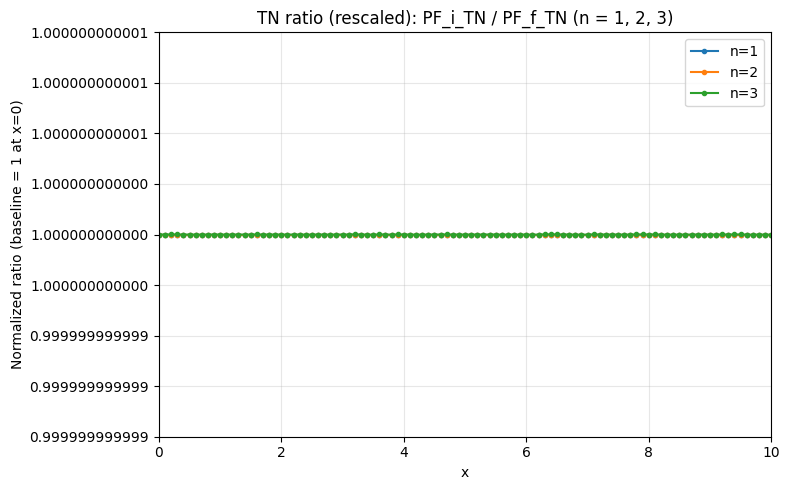

In [134]:
from pathlib import Path
from matplotlib.ticker import FormatStrFormatter

x_values = np.arange(0.0, 10.0 + 1e-9, 0.1)
n_values = [1, 2, 3]

out_dir = Path("tn_ratio_csv")
out_dir.mkdir(exist_ok=True)
png_path = out_dir / "TN_ratio.png"

plt.figure(figsize=(8, 5))
all_ratio_unit1 = []
for n in n_values:
    ratio_values = []
    for x in x_values:
        numerator = PF_i_TN(x, n)
        denominator = PF_f_TN(x / n, n)
        ratio_values.append(np.nan if np.isclose(denominator, 0.0) else numerator / denominator)

    ratio_values = np.array(ratio_values, dtype=float)

    # Re-define y-axis unit so each curve is around 1 (baseline at x=0).
    finite_idx = np.where(np.isfinite(ratio_values))[0]
    if finite_idx.size == 0:
        ratio_unit1 = np.full_like(ratio_values, np.nan, dtype=float)
    else:
        base = ratio_values[finite_idx[0]]
        ratio_unit1 = ratio_values / base

    all_ratio_unit1.append(ratio_unit1)
    plt.plot(x_values, ratio_unit1, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

    csv_path = out_dir / f"TN_ratio_n{n}.csv"
    data = np.column_stack((x_values, ratio_values, ratio_unit1))
    np.savetxt(
        csv_path,
        data,
        delimiter=",",
        header="x,PF_i_TN_div_PF_f_TN,PF_i_TN_div_PF_f_TN_unit1",
        comments="",
    )
    print(f"saved: {csv_path}")

# Make y-axis display around 1 directly (disable offset/scientific style).
all_ratio_unit1 = np.concatenate(all_ratio_unit1)
finite_vals = all_ratio_unit1[np.isfinite(all_ratio_unit1)]
center = np.nanmean(finite_vals) if finite_vals.size else 1.0
spread = np.nanmax(np.abs(finite_vals - center)) if finite_vals.size else 1e-12
pad = max(spread * 1.2, 1e-12)
plt.ylim(center - pad, center + pad)

ax = plt.gca()
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.12f"))

plt.xlabel("x")
plt.ylabel("Normalized ratio (baseline = 1 at x=0)")
plt.title("TN ratio (rescaled): PF_i_TN / PF_f_TN (n = 1, 2, 3)")
plt.xlim(0, 10)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(png_path, dpi=300, bbox_inches="tight")
print(f"saved: {png_path}")
plt.show()

In [93]:
PF_i_TN(12, 3) - PF_f_TN(12 / 3, 3)

0.0

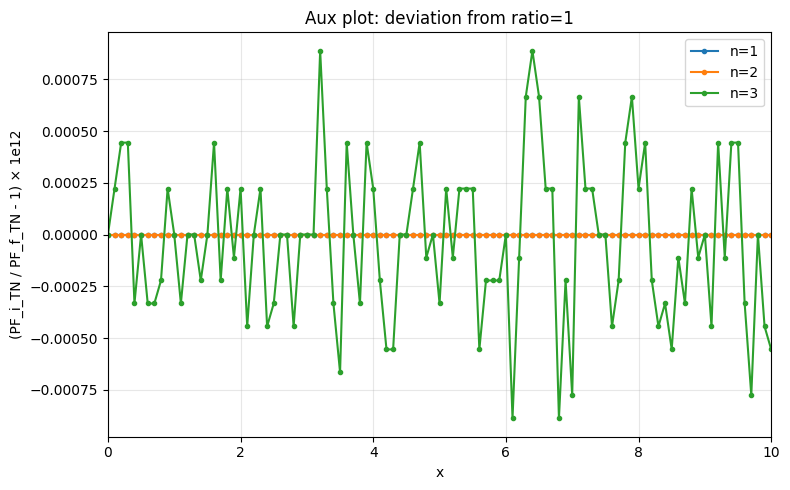

In [135]:
# 縦軸は (PF_i_TN / PF_f_TN - 1) × 1e12
x_values = np.arange(0.0, 10.0 + 1e-9, 0.1)
n_values = [1, 2, 3]

scale = 1e12  # visualize tiny deviation from 1
plt.figure(figsize=(8, 5))
for n in n_values:
    ratio_minus_1 = []
    for x in x_values:
        num = PF_i_TN(x, n)
        den = PF_f_TN(x / n, n)
        if np.isclose(den, 0.0):
            ratio_minus_1.append(np.nan)
        else:
            ratio_minus_1.append(num / den - 1.0)

    y = np.array(ratio_minus_1, dtype=float) * scale
    plt.plot(x_values, y, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

plt.xlabel("x")
plt.ylabel("(PF_i_TN / PF_f_TN - 1) × 1e12")
plt.title("Aux plot: deviation from ratio=1")
plt.xlim(0, 10)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(Path("tn_ratio_csv") / "TN_ratio_deviation.png", dpi=300, bbox_inches="tight")
plt.show()

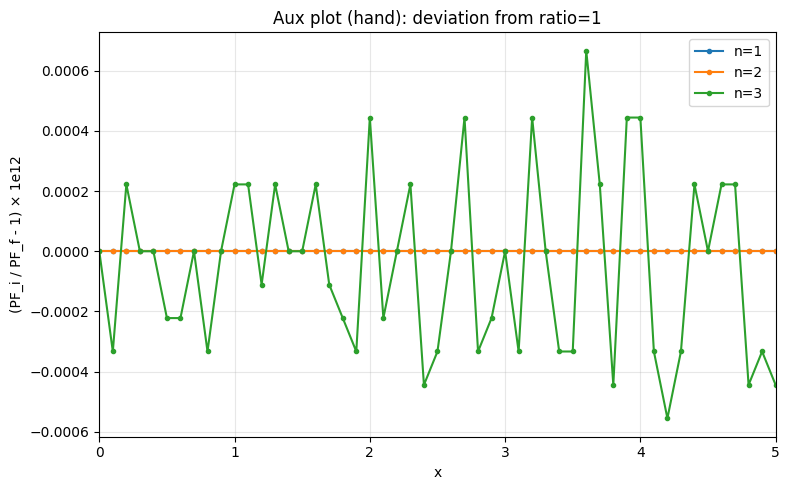

In [136]:
# 手計算側の補助プロット: 縦軸は (PF_i / PF_f - 1) × 1e12
x_values = np.arange(0.0, 5.0 + 1e-9, 0.1)
n_values = [1, 2, 3]

scale = 1e12
plt.figure(figsize=(8, 5))
for n in n_values:
    ratio_minus_1 = []
    for x in x_values:
        num = PF_i(x, n)
        den = PF_f(x / n, n)
        if np.isclose(den, 0.0):
            ratio_minus_1.append(np.nan)
        else:
            ratio_minus_1.append(num / den - 1.0)

    y = np.array(ratio_minus_1, dtype=float) * scale
    plt.plot(x_values, y, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

plt.xlabel("x")
plt.ylabel("(PF_i / PF_f - 1) × 1e12")
plt.title("Aux plot (hand): deviation from ratio=1")
plt.xlim(0, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 手計算と TN 計算を比較

saved: pf_i_vs_tn_csv/PF_i_vs_PF_i_TN_n1.csv
saved: pf_i_vs_tn_csv/PF_i_vs_PF_i_TN_n2.csv
saved: pf_i_vs_tn_csv/PF_i_vs_PF_i_TN_n3.csv
saved: pf_i_vs_tn_csv/PF_i_vs_PF_i_TN.png


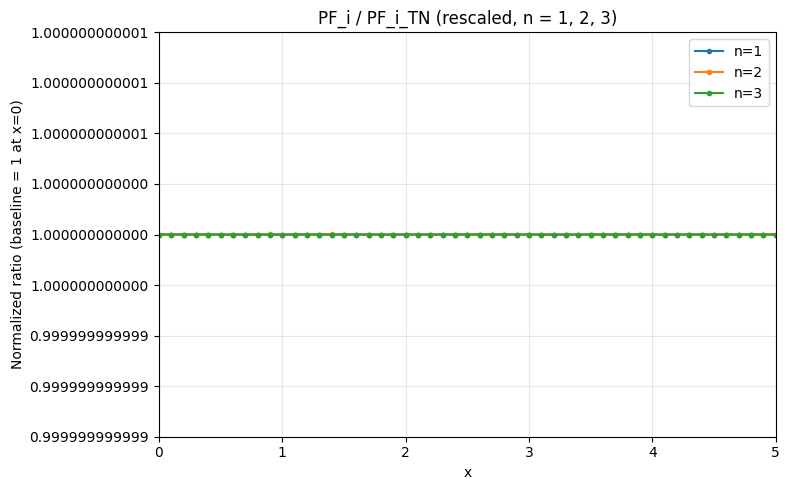

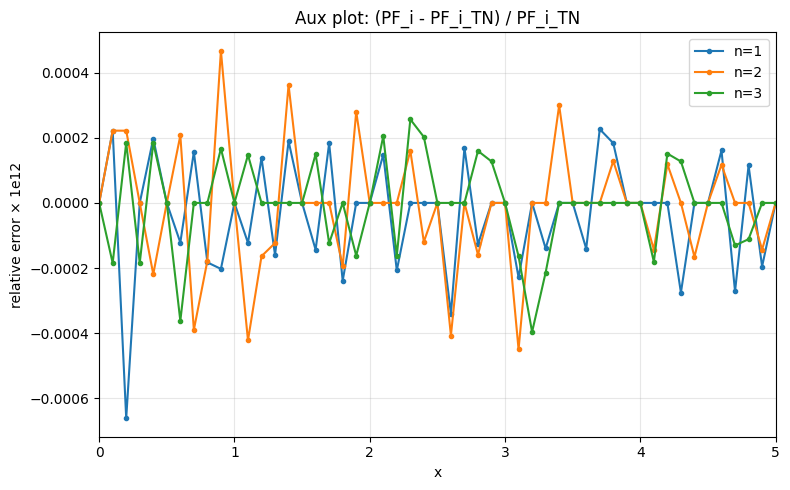

In [137]:
from pathlib import Path
from matplotlib.ticker import FormatStrFormatter

x_values = np.arange(0.0, 5.0 + 1e-9, 0.1)
n_values = [1, 2, 3]

out_dir = Path("pf_i_vs_tn_csv")
out_dir.mkdir(exist_ok=True)
png_path = out_dir / "PF_i_vs_PF_i_TN.png"

plt.figure(figsize=(8, 5))
all_ratio_unit1 = []
for n in n_values:
    ratio_values = []
    abs_error_values = []
    rel_error_values = []
    for x in x_values:
        pf_i_val = PF_i(x, n)
        pf_i_tn_val = PF_i_TN(x, n)
        if np.isclose(pf_i_tn_val, 0.0):
            ratio = np.nan
            rel_err = np.nan
        else:
            ratio = pf_i_val / pf_i_tn_val
            rel_err = (pf_i_val - pf_i_tn_val) / pf_i_tn_val
        ratio_values.append(ratio)
        abs_error_values.append(pf_i_val - pf_i_tn_val)
        rel_error_values.append(rel_err)

    ratio_values = np.array(ratio_values, dtype=float)
    abs_error_values = np.array(abs_error_values, dtype=float)
    rel_error_values = np.array(rel_error_values, dtype=float)

    finite_idx = np.where(np.isfinite(ratio_values))[0]
    if finite_idx.size == 0:
        ratio_unit1 = np.full_like(ratio_values, np.nan, dtype=float)
    else:
        base = ratio_values[finite_idx[0]]
        ratio_unit1 = ratio_values / base

    all_ratio_unit1.append(ratio_unit1)
    plt.plot(x_values, ratio_unit1, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

    csv_path = out_dir / f"PF_i_vs_PF_i_TN_n{n}.csv"
    data = np.column_stack((x_values, ratio_values, ratio_unit1, abs_error_values, rel_error_values))
    np.savetxt(
        csv_path,
        data,
        delimiter=",",
        header="x,PF_i_div_PF_i_TN,PF_i_div_PF_i_TN_unit1,abs_error,rel_error",
        comments="",
    )
    print(f"saved: {csv_path}")

all_ratio_unit1 = np.concatenate(all_ratio_unit1)
finite_vals = all_ratio_unit1[np.isfinite(all_ratio_unit1)]
center = np.nanmean(finite_vals) if finite_vals.size else 1.0
spread = np.nanmax(np.abs(finite_vals - center)) if finite_vals.size else 1e-12
pad = max(spread * 1.2, 1e-12)
plt.ylim(center - pad, center + pad)

ax = plt.gca()
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.12f"))

plt.xlabel("x")
plt.ylabel("Normalized ratio (baseline = 1 at x=0)")
plt.title("PF_i / PF_i_TN (rescaled, n = 1, 2, 3)")
plt.xlim(0, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(png_path, dpi=300, bbox_inches="tight")
print(f"saved: {png_path}")
plt.show()

scale = 1e12
plt.figure(figsize=(8, 5))
for n in n_values:
    rel_error_values = []
    for x in x_values:
        pf_i_tn_val = PF_i_TN(x, n)
        if np.isclose(pf_i_tn_val, 0.0):
            rel_error_values.append(np.nan)
        else:
            rel_error_values.append((PF_i(x, n) - pf_i_tn_val) / pf_i_tn_val)

    y = np.array(rel_error_values, dtype=float) * scale
    plt.plot(x_values, y, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

plt.xlabel("x")
plt.ylabel("relative error × 1e12")
plt.title("Aux plot: (PF_i - PF_i_TN) / PF_i_TN")
plt.xlim(0, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(Path("pf_i_vs_tn_csv") / "PF_i_vs_PF_i_TN_deviation.png", dpi=300, bbox_inches="tight")
plt.show()

In [97]:
PF_i(4, 1) - PF_i_TN(4, 1)

0.0

In [ ]:
"""
# Debug table for n=1: locate where PF_i and PF_i_TN diverge
import numpy as np
import pandas as pd

x_debug = np.arange(0.0, 5.0 + 1e-9, 0.5)
rows = []
for x in x_debug:
    pf_hand = PF_i(x, 1)
    pf_tn = PF_i_TN(x, 1)
    ratio = np.nan if np.isclose(pf_tn, 0.0) else pf_hand / pf_tn
    rel_err = np.nan if np.isclose(pf_tn, 0.0) else (pf_hand - pf_tn) / pf_tn
    rows.append((x, pf_hand, pf_tn, ratio, rel_err))

df_debug_n1 = pd.DataFrame(
    rows,
    columns=["x", "PF_i_hand", "PF_i_TN", "ratio_hand_div_tn", "rel_error"],
)

print(df_debug_n1.to_string(index=False))

# Save debug snapshot for further inspection
debug_path = Path("pf_i_vs_tn_csv") / "debug_n1_hand_vs_tn.csv"
df_debug_n1.to_csv(debug_path, index=False)
print(f"saved: {debug_path}")

print("\nTensor/intermediate check for n=1")
for x in [0.0, 2.0]:
    T_corner = CL3by3OBC_TensorI_Cornor(x, 1)
    T_link = CL3by3OBC_TensorI_Link(x, 1)
    T_center = CL3by3OBC_TensorI_Centor(x, 1)

    M1 = ncon([T_corner, T_link, T_corner], [[-1, 1], [1, -2, 2], [2, -3]])
    M3 = ncon([T_corner, T_link, T_corner], [[1, -1], [2, -2, 1], [-3, 2]])
    M2 = ncon([M1, T_link], [[1, -3, -4], [-1, -2, 1]])
    M2 = ncon([M2, T_center], [[-1, 1, 2, -4], [2, 1, -2, -3]])
    M2 = ncon([M2, T_link], [[-1, -2, 1, 2], [2, 1, -3]])
    pf_raw = ncon([M2, M3], [[1, 2, 3], [1, 2, 3]])

    print(f"x={x}")
    print(f"  corner[0,0]={float(T_corner[0,0])}")
    print(f"  link[0,0,0]={float(T_link[0,0,0])}")
    print(f"  center[0,0,0,0]={float(T_center[0,0,0,0])}")
    print(f"  M1={float(np.asarray(M1).reshape(()))}, M2={float(np.asarray(M2).reshape(()))}, M3={float(np.asarray(M3).reshape(()))}")
    print(f"  pf_raw(before 2**9 factor)={float(np.asarray(pf_raw).reshape(()))}")
"""

  x    PF_i_hand      PF_i_TN  ratio_hand_div_tn  rel_error
0.0        512.0        512.0                1.0        0.0
0.5        686.0        686.0                1.0        0.0
1.0       8192.0       8192.0                1.0        0.0
1.5     126062.0     126062.0                1.0        0.0
2.0    1081856.0    1081856.0                1.0        0.0
2.5    6049262.0    6049262.0                1.0        0.0
3.0   25174016.0   25174016.0                1.0        0.0
3.5   84779822.0   84779822.0                1.0        0.0
4.0  243794432.0  243794432.0                1.0        0.0
4.5  620500526.0  620500526.0                1.0        0.0
5.0 1433280512.0 1433280512.0                1.0        0.0
saved: pf_i_vs_tn_csv/debug_n1_hand_vs_tn.csv

Tensor/intermediate check for n=1
x=0.0
  corner[0,0]=1.0
  link[0,0,0]=1.0
  center[0,0,0,0]=1.0


ValueError: cannot reshape array of size 8 into shape ()

saved: pf_i_vs_pf_f_tn_csv/PF_i_div_PF_f_TN_n1.csv
saved: pf_i_vs_pf_f_tn_csv/PF_i_div_PF_f_TN_n2.csv
saved: pf_i_vs_pf_f_tn_csv/PF_i_div_PF_f_TN_n3.csv
saved: pf_i_vs_pf_f_tn_csv/PF_i_div_PF_f_TN.png


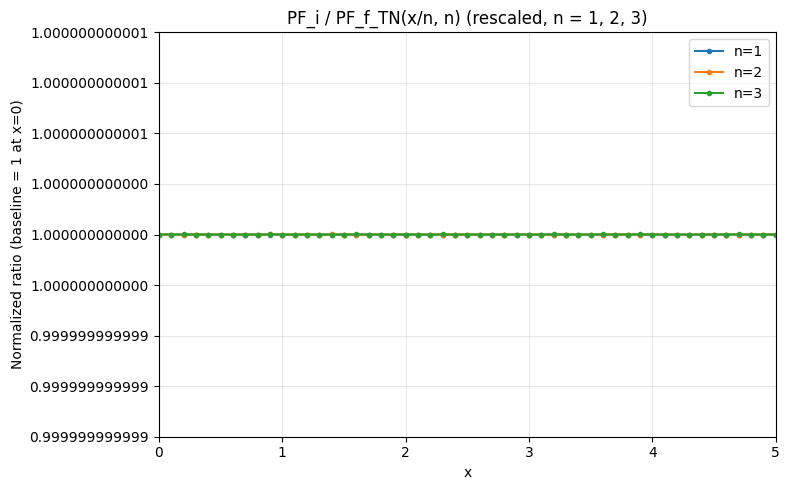

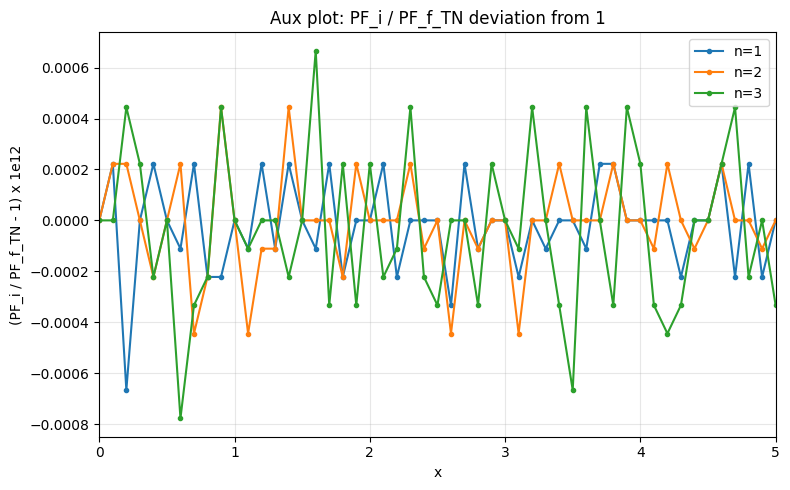

In [138]:
from pathlib import Path
from matplotlib.ticker import FormatStrFormatter

x_values = np.arange(0.0, 5.0 + 1e-9, 0.1)
n_values = [1, 2, 3]

out_dir = Path("pf_i_vs_pf_f_tn_csv")
out_dir.mkdir(exist_ok=True)
png_path = out_dir / "PF_i_div_PF_f_TN.png"

plt.figure(figsize=(8, 5))
all_ratio_unit1 = []
for n in n_values:
    ratio_values = []
    for x in x_values:
        numerator = PF_i(x, n)
        denominator = PF_f_TN(x / n, n)
        ratio_values.append(np.nan if np.isclose(denominator, 0.0) else numerator / denominator)

    ratio_values = np.array(ratio_values, dtype=float)

    finite_idx = np.where(np.isfinite(ratio_values))[0]
    if finite_idx.size == 0:
        ratio_unit1 = np.full_like(ratio_values, np.nan, dtype=float)
    else:
        base = ratio_values[finite_idx[0]]
        ratio_unit1 = ratio_values / base

    all_ratio_unit1.append(ratio_unit1)
    plt.plot(x_values, ratio_unit1, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

    csv_path = out_dir / f"PF_i_div_PF_f_TN_n{n}.csv"
    data = np.column_stack((x_values, ratio_values, ratio_unit1))
    np.savetxt(
        csv_path,
        data,
        delimiter=",",
        header="x,PF_i_div_PF_f_TN,PF_i_div_PF_f_TN_unit1",
        comments="",
    )
    print(f"saved: {csv_path}")

all_ratio_unit1 = np.concatenate(all_ratio_unit1)
finite_vals = all_ratio_unit1[np.isfinite(all_ratio_unit1)]
center = np.nanmean(finite_vals) if finite_vals.size else 1.0
spread = np.nanmax(np.abs(finite_vals - center)) if finite_vals.size else 1e-12
pad = max(spread * 1.2, 1e-12)
plt.ylim(center - pad, center + pad)

ax = plt.gca()
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.12f"))

plt.xlabel("x")
plt.ylabel("Normalized ratio (baseline = 1 at x=0)")
plt.title("PF_i / PF_f_TN(x/n, n) (rescaled, n = 1, 2, 3)")
plt.xlim(0, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(png_path, dpi=300, bbox_inches="tight")
print(f"saved: {png_path}")
plt.show()

# Auxiliary plot: (ratio - 1) x 1e12
scale = 1e12
plt.figure(figsize=(8, 5))
for n in n_values:
    ratio_minus_1 = []
    for x in x_values:
        num = PF_i(x, n)
        den = PF_f_TN(x / n, n)
        if np.isclose(den, 0.0):
            ratio_minus_1.append(np.nan)
        else:
            ratio_minus_1.append(num / den - 1.0)

    y = np.array(ratio_minus_1, dtype=float) * scale
    plt.plot(x_values, y, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

plt.xlabel("x")
plt.ylabel("(PF_i / PF_f_TN - 1) x 1e12")
plt.title("Aux plot: PF_i / PF_f_TN deviation from 1")
plt.xlim(0, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(Path("pf_i_vs_pf_f_tn_csv") / "PF_i_div_PF_f_TN_deviation.png", dpi=300, bbox_inches="tight")
plt.show()

saved: pf_f_vs_pf_i_tn_csv/PF_f_div_PF_i_TN_n1.csv
saved: pf_f_vs_pf_i_tn_csv/PF_f_div_PF_i_TN_n2.csv
saved: pf_f_vs_pf_i_tn_csv/PF_f_div_PF_i_TN_n3.csv
saved: pf_f_vs_pf_i_tn_csv/PF_f_div_PF_i_TN.png


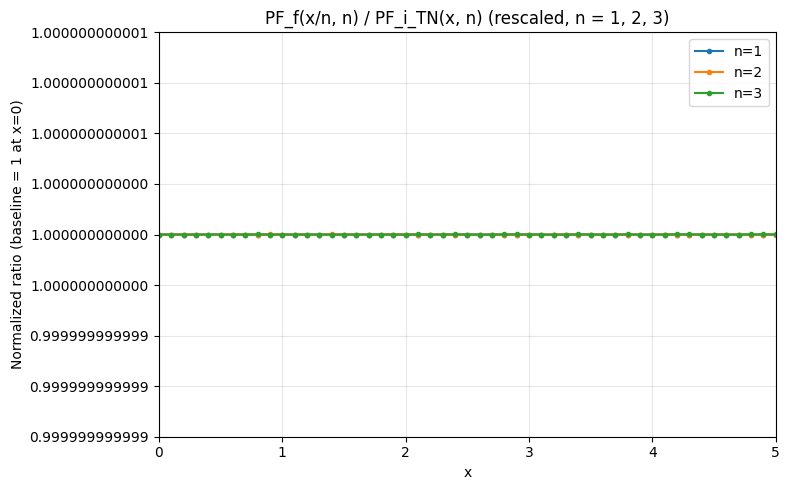

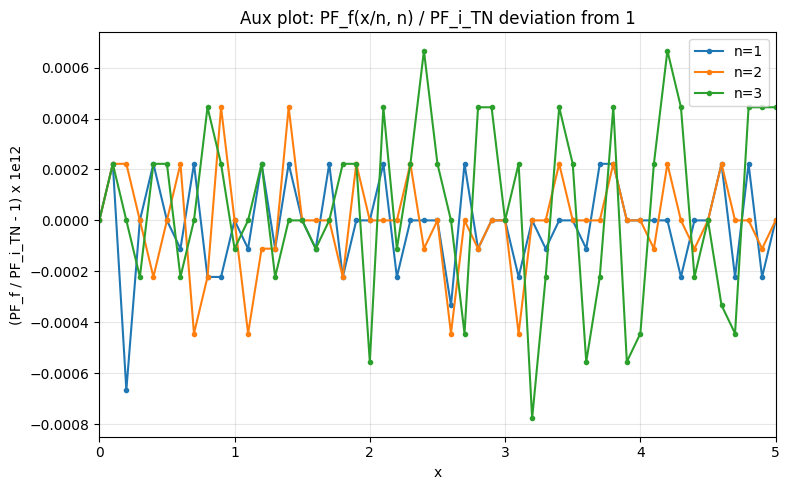

In [139]:
from pathlib import Path
from matplotlib.ticker import FormatStrFormatter

x_values = np.arange(0.0, 5.0 + 1e-9, 0.1)
n_values = [1, 2, 3]

out_dir = Path("pf_f_vs_pf_i_tn_csv")
out_dir.mkdir(exist_ok=True)
png_path = out_dir / "PF_f_div_PF_i_TN.png"

plt.figure(figsize=(8, 5))
all_ratio_unit1 = []
for n in n_values:
    ratio_values = []
    for x in x_values:
        numerator = PF_f(x / n, n)
        denominator = PF_i_TN(x, n)
        ratio_values.append(np.nan if np.isclose(denominator, 0.0) else numerator / denominator)

    ratio_values = np.array(ratio_values, dtype=float)

    finite_idx = np.where(np.isfinite(ratio_values))[0]
    if finite_idx.size == 0:
        ratio_unit1 = np.full_like(ratio_values, np.nan, dtype=float)
    else:
        base = ratio_values[finite_idx[0]]
        ratio_unit1 = ratio_values / base

    all_ratio_unit1.append(ratio_unit1)
    plt.plot(x_values, ratio_unit1, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

    csv_path = out_dir / f"PF_f_div_PF_i_TN_n{n}.csv"
    data = np.column_stack((x_values, ratio_values, ratio_unit1))
    np.savetxt(
        csv_path,
        data,
        delimiter=",",
        header="x,PF_f_div_PF_i_TN,PF_f_div_PF_i_TN_unit1",
        comments="",
    )
    print(f"saved: {csv_path}")

all_ratio_unit1 = np.concatenate(all_ratio_unit1)
finite_vals = all_ratio_unit1[np.isfinite(all_ratio_unit1)]
center = np.nanmean(finite_vals) if finite_vals.size else 1.0
spread = np.nanmax(np.abs(finite_vals - center)) if finite_vals.size else 1e-12
pad = max(spread * 1.2, 1e-12)
plt.ylim(center - pad, center + pad)

ax = plt.gca()
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.12f"))

plt.xlabel("x")
plt.ylabel("Normalized ratio (baseline = 1 at x=0)")
plt.title("PF_f(x/n, n) / PF_i_TN(x, n) (rescaled, n = 1, 2, 3)")
plt.xlim(0, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(png_path, dpi=300, bbox_inches="tight")
print(f"saved: {png_path}")
plt.show()

# Auxiliary plot: (ratio - 1) x 1e12
scale = 1e12
plt.figure(figsize=(8, 5))
for n in n_values:
    ratio_minus_1 = []
    for x in x_values:
        num = PF_f(x / n, n)
        den = PF_i_TN(x, n)
        if np.isclose(den, 0.0):
            ratio_minus_1.append(np.nan)
        else:
            ratio_minus_1.append(num / den - 1.0)

    y = np.array(ratio_minus_1, dtype=float) * scale
    plt.plot(x_values, y, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

plt.xlabel("x")
plt.ylabel("(PF_f / PF_i_TN - 1) x 1e12")
plt.title("Aux plot: PF_f(x/n, n) / PF_i_TN deviation from 1")
plt.xlim(0, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(Path("pf_f_vs_pf_i_tn_csv") / "PF_f_div_PF_i_TN_deviation.png", dpi=300, bbox_inches="tight")
plt.show()

saved: pf_f_vs_pf_f_tn_csv/PF_f_div_PF_f_TN_n1.csv
saved: pf_f_vs_pf_f_tn_csv/PF_f_div_PF_f_TN_n2.csv
saved: pf_f_vs_pf_f_tn_csv/PF_f_div_PF_f_TN_n3.csv
saved: pf_f_vs_pf_f_tn_csv/PF_f_div_PF_f_TN.png


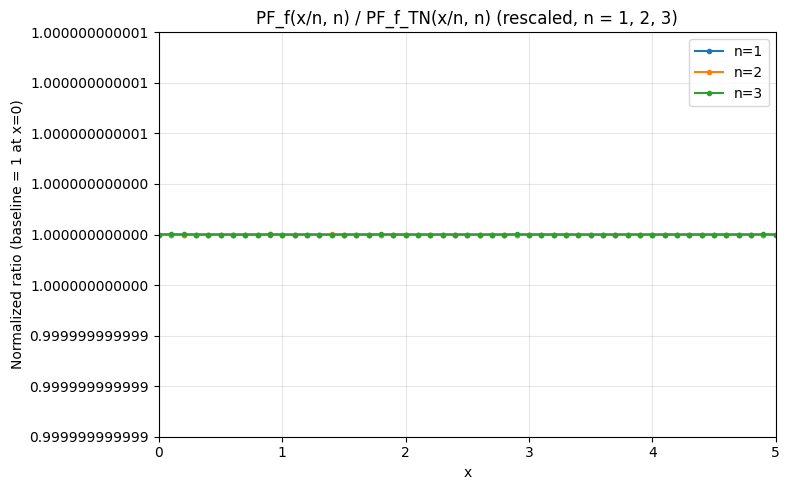

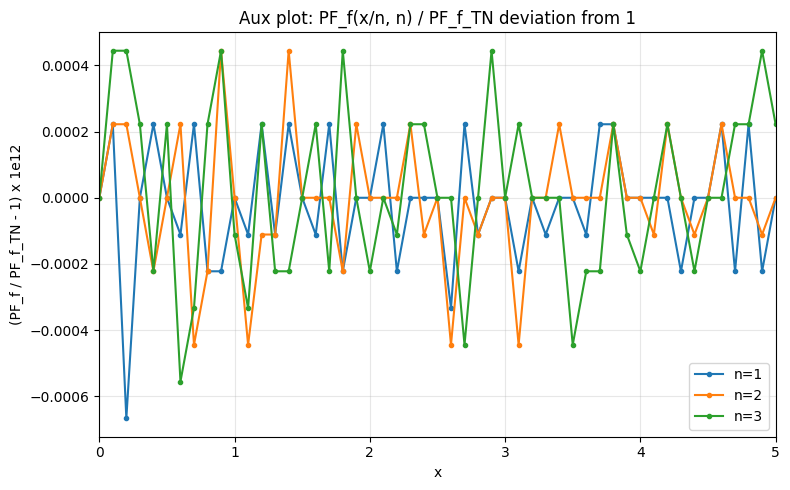

In [140]:
from pathlib import Path
from matplotlib.ticker import FormatStrFormatter

x_values = np.arange(0.0, 5.0 + 1e-9, 0.1)
n_values = [1, 2, 3]

out_dir = Path("pf_f_vs_pf_f_tn_csv")
out_dir.mkdir(exist_ok=True)
png_path = out_dir / "PF_f_div_PF_f_TN.png"

plt.figure(figsize=(8, 5))
all_ratio_unit1 = []
for n in n_values:
    ratio_values = []
    for x in x_values:
        numerator = PF_f(x / n, n)
        denominator = PF_f_TN(x / n, n)
        ratio_values.append(np.nan if np.isclose(denominator, 0.0) else numerator / denominator)

    ratio_values = np.array(ratio_values, dtype=float)

    finite_idx = np.where(np.isfinite(ratio_values))[0]
    if finite_idx.size == 0:
        ratio_unit1 = np.full_like(ratio_values, np.nan, dtype=float)
    else:
        base = ratio_values[finite_idx[0]]
        ratio_unit1 = ratio_values / base

    all_ratio_unit1.append(ratio_unit1)
    plt.plot(x_values, ratio_unit1, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

    csv_path = out_dir / f"PF_f_div_PF_f_TN_n{n}.csv"
    data = np.column_stack((x_values, ratio_values, ratio_unit1))
    np.savetxt(
        csv_path,
        data,
        delimiter=",",
        header="x,PF_f_div_PF_f_TN,PF_f_div_PF_f_TN_unit1",
        comments="",
    )
    print(f"saved: {csv_path}")

all_ratio_unit1 = np.concatenate(all_ratio_unit1)
finite_vals = all_ratio_unit1[np.isfinite(all_ratio_unit1)]
center = np.nanmean(finite_vals) if finite_vals.size else 1.0
spread = np.nanmax(np.abs(finite_vals - center)) if finite_vals.size else 1e-12
pad = max(spread * 1.2, 1e-12)
plt.ylim(center - pad, center + pad)

ax = plt.gca()
ax.ticklabel_format(axis="y", style="plain", useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter("%.12f"))

plt.xlabel("x")
plt.ylabel("Normalized ratio (baseline = 1 at x=0)")
plt.title("PF_f(x/n, n) / PF_f_TN(x/n, n) (rescaled, n = 1, 2, 3)")
plt.xlim(0, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(png_path, dpi=300, bbox_inches="tight")
print(f"saved: {png_path}")
plt.show()

# Auxiliary plot: (ratio - 1) x 1e12
scale = 1e12
plt.figure(figsize=(8, 5))
for n in n_values:
    ratio_minus_1 = []
    for x in x_values:
        num = PF_f(x / n, n)
        den = PF_f_TN(x / n, n)
        if np.isclose(den, 0.0):
            ratio_minus_1.append(np.nan)
        else:
            ratio_minus_1.append(num / den - 1.0)

    y = np.array(ratio_minus_1, dtype=float) * scale
    plt.plot(x_values, y, marker="o", markersize=3, linewidth=1.5, label=f"n={n}")

plt.xlabel("x")
plt.ylabel("(PF_f / PF_f_TN - 1) x 1e12")
plt.title("Aux plot: PF_f(x/n, n) / PF_f_TN deviation from 1")
plt.xlim(0, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(Path("pf_f_vs_pf_f_tn_csv") / "PF_f_div_PF_f_TN_deviation.png", dpi=300, bbox_inches="tight")
plt.show()